# Conectar el drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
%cd /content/drive/MyDrive/Colab Notebooks/Preprocesamiento de datos
!ls

[WinError 3] El sistema no puede encontrar la ruta especificada: '/content/drive/MyDrive/Colab Notebooks/Preprocesamiento de datos'
c:\Users\user\OneDrive\Documentos\DIPLOMADO\PRIMER MODULO\taller-data-science-rama2-Santiago\Dataset_python


"ls" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [3]:
headers = ["symboling","normalized-losses","make","fuel-type","aspiration", "num-of-doors","body-style",
         "drive-wheels","engine-location","wheel-base", "length","width","height","curb-weight","engine-type",
         "num-of-cylinders", "engine-size","fuel-system","bore","stroke","compression-ratio","horsepower",
         "peak-rpm","city-mpg","highway-mpg","price"]

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib

Using matplotlib backend: module://matplotlib_inline.backend_inline


In [7]:
## Cargar los archivos.
file_name = 'auto.csv'
df = pd.read_csv(file_name, names=headers)
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


# Identificar datos faltantes.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    str    
 2   make               205 non-null    str    
 3   fuel-type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       205 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size        205 non-null    in

In [9]:
df["normalized-losses"].unique()

<StringArray>
[  '?', '164', '158', '192', '188', '121',  '98',  '81', '118', '148', '110',
 '145', '137', '101',  '78', '106',  '85', '107', '104', '113', '150', '129',
 '115',  '93', '142', '161', '153', '125', '128', '122', '103', '168', '108',
 '194', '231', '119', '154',  '74', '186',  '83', '102',  '89',  '87',  '77',
  '91', '134',  '65', '197',  '90',  '94', '256',  '95']
Length: 52, dtype: str

In [10]:
## remplazar los datos
df.replace("?", np.nan, inplace=True)
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [11]:
df["normalized-losses"].unique()

<StringArray>
[  nan, '164', '158', '192', '188', '121',  '98',  '81', '118', '148', '110',
 '145', '137', '101',  '78', '106',  '85', '107', '104', '113', '150', '129',
 '115',  '93', '142', '161', '153', '125', '128', '122', '103', '168', '108',
 '194', '231', '119', '154',  '74', '186',  '83', '102',  '89',  '87',  '77',
  '91', '134',  '65', '197',  '90',  '94', '256',  '95']
Length: 52, dtype: str

In [12]:
# Verificar los datos faltantes.
missing_data = df.isnull()
missing_data.head(5)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [13]:
# Verificar que columnas tiene datos faltantes
missing_data['normalized-losses'].value_counts()

normalized-losses
False    164
True      41
Name: count, dtype: int64

In [14]:
for column in missing_data.columns.values.tolist():
    print(column)
    print (missing_data[column].value_counts())
    print("")

symboling
symboling
False    205
Name: count, dtype: int64

normalized-losses
normalized-losses
False    164
True      41
Name: count, dtype: int64

make
make
False    205
Name: count, dtype: int64

fuel-type
fuel-type
False    205
Name: count, dtype: int64

aspiration
aspiration
False    205
Name: count, dtype: int64

num-of-doors
num-of-doors
False    203
True       2
Name: count, dtype: int64

body-style
body-style
False    205
Name: count, dtype: int64

drive-wheels
drive-wheels
False    205
Name: count, dtype: int64

engine-location
engine-location
False    205
Name: count, dtype: int64

wheel-base
wheel-base
False    205
Name: count, dtype: int64

length
length
False    205
Name: count, dtype: int64

width
width
False    205
Name: count, dtype: int64

height
height
False    205
Name: count, dtype: int64

curb-weight
curb-weight
False    205
Name: count, dtype: int64

engine-type
engine-type
False    205
Name: count, dtype: int64

num-of-cylinders
num-of-cylinders
False    205
Nam

# Calcular la media de los valores the normalizacion

In [15]:
# Calcular la media de los valores the normalized-losses column
avf_normalized_losses = df["normalized-losses"].astype("float").mean(axis=0)
print("Average of normalized-losses:", avf_normalized_losses)

Average of normalized-losses: 122.0


In [16]:
# Remplazar "NaN" con el valor medio "normalized-losses"
df["normalized-losses"].replace(np.nan, avf_normalized_losses, inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_21380\3914102532.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["normalized-losses"].replace(np.nan, avf_normalized_losses, inplace=True)


0      122.0
1      122.0
2      122.0
3        164
4        164
       ...  
200       95
201       95
202       95
203       95
204       95
Name: normalized-losses, Length: 205, dtype: object

In [17]:
# Calcula el valor medio de la columna "diámetro"
avg_bore=df['bore'].astype('float').mean(axis=0)
print("Average of bore:", avg_bore)

Average of bore: 3.3297512437810943


# Replace "NaN" with the mean value in the "bore" column

In [18]:
df["bore"].replace(np.nan, avg_bore, inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_21380\1952189479.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["bore"].replace(np.nan, avg_bore, inplace=True)


0      3.47
1      3.47
2      2.68
3      3.19
4      3.19
       ... 
200    3.78
201    3.78
202    3.58
203    3.01
204    3.78
Name: bore, Length: 205, dtype: object

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Pregunta n.° 1: </h1>

<b>Según el ejemplo anterior, sustituya NaN en la columna "stroke" por el valor medio.</b>
</div>

In [19]:
### you code  ###
print("\n=== PREGUNTA 1: REEMPLAZAR STROKE CON LA MEDIA ===")
avg_stroke = df['stroke'].astype('float').mean(axis=0)
print(f"Media de stroke: {avg_stroke:.2f}")
df["stroke"].replace(np.nan, avg_stroke, inplace=True)


=== PREGUNTA 1: REEMPLAZAR STROKE CON LA MEDIA ===
Media de stroke: 3.26


C:\Users\user\AppData\Local\Temp\ipykernel_21380\2862196270.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["stroke"].replace(np.nan, avg_stroke, inplace=True)


0      2.68
1      2.68
2      3.47
3      3.40
4      3.40
       ... 
200    3.15
201    3.15
202    2.87
203    3.40
204    3.15
Name: stroke, Length: 205, dtype: object

Calcula el valor medio de la columna "caballos de fuerza".

Reemplace "NaN" con el valor medio de la columna "horsepower".

In [20]:
avg_horsepower = df['horsepower'].astype('float').mean(axis=0)
print("Average horsepower:", avg_horsepower)

df['horsepower'].replace(np.nan, avg_horsepower, inplace=True)

Average horsepower: 104.25615763546799


C:\Users\user\AppData\Local\Temp\ipykernel_21380\2938226892.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['horsepower'].replace(np.nan, avg_horsepower, inplace=True)


0      111
1      111
2      154
3      102
4      115
      ... 
200    114
201    160
202    134
203    106
204    114
Name: horsepower, Length: 205, dtype: object

# Calcula el valor medio de la columna "peak-rpm".

# Replace "NaN" with the mean value in the "peak-rpm" column

In [21]:
avg_peakrpm=df['peak-rpm'].astype('float').mean(axis=0)
print("Average peak rpm:", avg_peakrpm)

df['peak-rpm'].replace(np.nan, avg_peakrpm, inplace=True)

Average peak rpm: 5125.369458128079


C:\Users\user\AppData\Local\Temp\ipykernel_21380\3031431570.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['peak-rpm'].replace(np.nan, avg_peakrpm, inplace=True)


0      5000
1      5000
2      5000
3      5500
4      5500
       ... 
200    5400
201    5300
202    5500
203    4800
204    5400
Name: peak-rpm, Length: 205, dtype: object

# Para ver qué valores están presentes en una columna en particular, podemos usar el método ".value_counts()":

#

In [22]:
df['num-of-doors'].value_counts()

num-of-doors
four    114
two      89
Name: count, dtype: int64

In [23]:
df['num-of-doors'].value_counts().idxmax()
#replace the missing 'num-of-doors' values by the most frequent
df["num-of-doors"].replace(np.nan, "four", inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_21380\1031221864.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["num-of-doors"].replace(np.nan, "four", inplace=True)


0       two
1       two
2       two
3      four
4      four
       ... 
200    four
201    four
202    four
203    four
204    four
Name: num-of-doors, Length: 205, dtype: str

# Finalmente, elimine todas las filas que no contengan datos de precio:

In [24]:
# simply drop whole row with NaN in "price" column
df.dropna(subset=["price"], axis=0, inplace=True)

# reset index, because we droped two rows
df.reset_index(drop=True, inplace=True)

In [25]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


# Formato de datos correcto

In [26]:
df.dtypes

symboling              int64
normalized-losses        str
make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                     str
stroke                   str
compression-ratio    float64
horsepower               str
peak-rpm                 str
city-mpg               int64
highway-mpg            int64
price                    str
dtype: object

# Convierta los tipos de datos al formato adecuado.

In [28]:
# =============================================
# REEMPLAZAR DATOS FALTANTES - VERSIÓN CORREGIDA
# =============================================

print("\n=== VERIFICANDO DATOS FALTANTES ANTES DE CONVERTIR ===")

# Verificar valores nulos en todas las columnas que vamos a convertir
columns_to_check = ['normalized-losses', 'bore', 'stroke', 'peak-rpm', 'horsepower', 'price']
for col in columns_to_check:
    null_count = df[col].isnull().sum()
    print(f"{col}: {null_count} valores nulos")

# =============================================
# PASO 1: REEMPLAZAR TODOS LOS VALORES FALTANTES
# =============================================

print("\n=== REEMPLAZANDO TODOS LOS VALORES FALTANTES ===")

# 1. Reemplazar normalized-losses con la media
avg_normalized_losses = df["normalized-losses"].astype("float").mean(axis=0)
print(f"Media de normalized-losses: {avg_normalized_losses:.2f}")
df["normalized-losses"].fillna(avg_normalized_losses, inplace=True)

# 2. Reemplazar bore con la media
avg_bore = df['bore'].astype('float').mean(axis=0)
print(f"Media de bore: {avg_bore:.2f}")
df["bore"].fillna(avg_bore, inplace=True)

# 3. Reemplazar stroke con la media
avg_stroke = df['stroke'].astype('float').mean(axis=0)
print(f"Media de stroke: {avg_stroke:.2f}")
df["stroke"].fillna(avg_stroke, inplace=True)

# 4. Reemplazar horsepower con la media
avg_horsepower = df['horsepower'].astype('float').mean(axis=0)
print(f"Media de horsepower: {avg_horsepower:.2f}")
df['horsepower'].fillna(avg_horsepower, inplace=True)

# 5. Reemplazar peak-rpm con la media
avg_peakrpm = df['peak-rpm'].astype('float').mean(axis=0)
print(f"Media de peak-rpm: {avg_peakrpm:.2f}")
df['peak-rpm'].fillna(avg_peakrpm, inplace=True)

# 6. Reemplazar num-of-doors con la moda
print("\nValores únicos en num-of-doors:")
print(df['num-of-doors'].value_counts())
most_frequent = df['num-of-doors'].value_counts().idxmax()
print(f"Valor más frecuente: {most_frequent}")
df["num-of-doors"].fillna(most_frequent, inplace=True)

# 7. Eliminar filas sin precio
print("\n=== ELIMINANDO FILAS SIN PRECIO ===")
print(f"Filas antes de eliminar: {len(df)}")
df.dropna(subset=["price"], axis=0, inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Filas después de eliminar: {len(df)}")

# =============================================
# PASO 2: VERIFICAR QUE NO HAYAN QUEDADO NULOS
# =============================================

print("\n=== VERIFICANDO DATOS FALTANTES DESPUÉS DE REEMPLAZAR ===")
for col in columns_to_check:
    null_count = df[col].isnull().sum()
    print(f"{col}: {null_count} valores nulos")

# Si aún hay nulos, los eliminamos
if df[columns_to_check].isnull().sum().sum() > 0:
    print("\n⚠️ Aún hay valores nulos, eliminando esas filas...")
    df.dropna(subset=columns_to_check, inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"Filas después de eliminar nulos: {len(df)}")

# =============================================
# PASO 3: CONVERTIR TIPOS DE DATOS
# =============================================

print("\n=== CORRIGIENDO TIPOS DE DATOS ===")
print("Tipos de datos antes:")
print(df.dtypes)

# Convertir tipos de datos - USANDO .fillna() en lugar de .replace()
try:
    df[["bore", "stroke"]] = df[["bore", "stroke"]].astype("float")
    print("✅ bore y stroke convertidos a float")
except Exception as e:
    print(f"❌ Error en bore/stroke: {e}")

try:
    df[["normalized-losses"]] = df[["normalized-losses"]].astype("float").astype("int")
    print("✅ normalized-losses convertido a int")
except Exception as e:
    print(f"❌ Error en normalized-losses: {e}")

try:
    df[["price"]] = df[["price"]].astype("float")
    print("✅ price convertido a float")
except Exception as e:
    print(f"❌ Error en price: {e}")

try:
    df[["peak-rpm"]] = df[["peak-rpm"]].astype("float")
    print("✅ peak-rpm convertido a float")
except Exception as e:
    print(f"❌ Error en peak-rpm: {e}")

try:
    df[["horsepower"]] = df[["horsepower"]].astype("float")
    print("✅ horsepower convertido a float")
except Exception as e:
    print(f"❌ Error en horsepower: {e}")

print("\nTipos de datos después:")
print(df.dtypes)

# =============================================
# PASO 4: VERIFICACIÓN FINAL
# =============================================

print("\n=== VERIFICACIÓN FINAL ===")
print("Primeras 5 filas:")
print(df.head())
print("\nEstadísticas descriptivas:")
print(df[['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']].describe())


=== VERIFICANDO DATOS FALTANTES ANTES DE CONVERTIR ===
normalized-losses: 37 valores nulos
bore: 4 valores nulos
stroke: 4 valores nulos
peak-rpm: 2 valores nulos
horsepower: 2 valores nulos
price: 0 valores nulos

=== REEMPLAZANDO TODOS LOS VALORES FALTANTES ===
Media de normalized-losses: 122.00


C:\Users\user\AppData\Local\Temp\ipykernel_21380\1600021618.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["normalized-losses"].fillna(avg_normalized_losses, inplace=True)


TypeError: Invalid value '122.0' for dtype 'str'. Value should be a string or missing value, got 'float64' instead.

# Estandarización de datos

In [29]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [30]:
# Convert mpg to L/100km by mathematical operation (235 divided by mpg)
df['city-L/100km'] = 235/df["city-mpg"]

# check your transformed data
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495,11.190476
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500,11.190476
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500,12.368421
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950,9.791667
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450,13.055556


Tarea: }
Pregunta n.º 2:  Según el ejemplo anterior, transforme el valor de mpg a L/100km en la columna "highway-mpg" y cambie el nombre de la columna a "highway-L/100km".

In [31]:
## tu codigo
# transform mpg to L/100km by mathematical operation (235 divided by mpg)
df["highway-mpg"] = 235/df["highway-mpg"]

# rename column name from "highway-mpg" to "highway-L/100km"
df.rename(columns={'"highway-mpg"':'highway-L/100km'}, inplace=True)

# check your transformed data
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,8.703704,13495,11.190476
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,8.703704,16500,11.190476
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000,19,9.038462,16500,12.368421
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500,24,7.833333,13950,9.791667
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115,5500,18,10.681818,17450,13.055556


# Normalización de datos

In [32]:
# replace (original value) by (original value)/(maximum value)
df['length'] = df['length']/df['length'].max()
df['width'] = df['width']/df['width'].max()

In [279]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000.0,21,8.703704,13495.0,11.190476
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000.0,21,8.703704,16500.0,11.190476
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000.0,19,9.038462,16500.0,12.368421
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500.0,24,7.833333,13950.0,9.791667
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115,5500.0,18,10.681818,17450.0,13.055556


Pregunta n.º 3: Según el ejemplo anterior, normalice la columna "altura".

In [33]:
### tu codigo ###


# Example of Binning Data In Pandas

In [36]:
df["horsepower"] = pd.to_numeric(df["horsepower"], errors='coerce')

# 2. Como los números enteros estándar no aceptan NaN, puedes usar 'Int64' (con I mayúscula)
df["horsepower"] = df["horsepower"].astype("Int64")

Text(0.5, 1.0, 'horsepower bins')

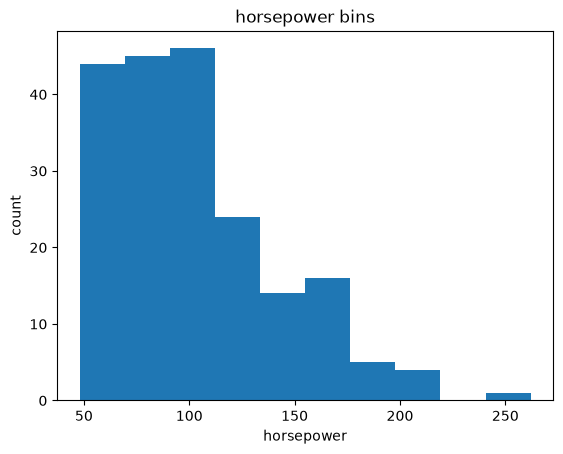

In [37]:
%matplotlib inline
import matplotlib as plt
from matplotlib import pyplot
plt.pyplot.hist(df["horsepower"])

# set x/y labels and plot title
plt.pyplot.xlabel("horsepower")
plt.pyplot.ylabel("count")
plt.pyplot.title("horsepower bins")

In [39]:
bins = np.linspace(df["horsepower"].min(), df["horsepower"].max(), 4)
bins

array([ 48.        , 119.33333333, 190.66666667, 262.        ])

In [40]:
group_names = ['Low', 'Medium', 'High']

In [41]:
df['horsepower-binned'] = pd.cut(df['horsepower'], bins, labels=group_names, include_lowest=True )
df[['horsepower','horsepower-binned']].head(20)

,horsepower,horsepower-binned
0,111,Low
1,111,Low
2,154,Medium
3,102,Low
4,115,Low
5,110,Low
6,110,Low
7,110,Low
8,140,Medium
9,101,Low


In [42]:
df["horsepower-binned"].value_counts()

horsepower-binned
Low       151
Medium     43
High        5
Name: count, dtype: int64

Text(0.5, 1.0, 'horsepower bins')

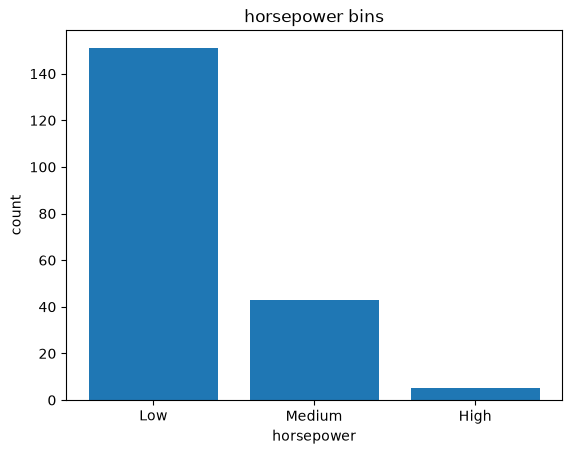

In [43]:
%matplotlib inline
import matplotlib as plt
from matplotlib import pyplot
###
pyplot.bar(group_names, df["horsepower-binned"].value_counts())

# set x/y labels and plot title
plt.pyplot.xlabel("horsepower")
plt.pyplot.ylabel("count")
plt.pyplot.title("horsepower bins")

Text(0.5, 1.0, 'horsepower bins')

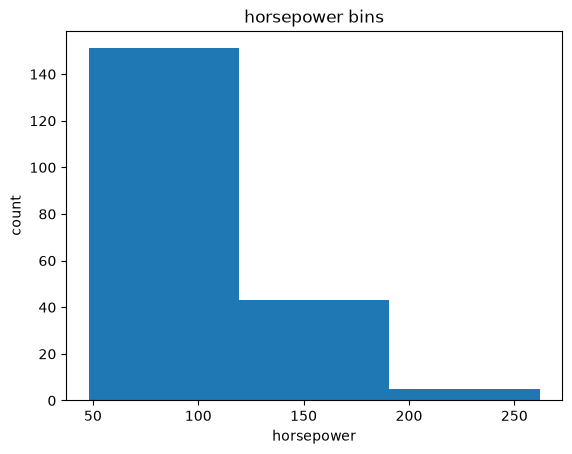

In [44]:
%matplotlib inline
import matplotlib as plt
from matplotlib import pyplot


# draw historgram of attribute "horsepower" with bins = 3
plt.pyplot.hist(df["horsepower"], bins = 3)

# set x/y labels and plot title
plt.pyplot.xlabel("horsepower")
plt.pyplot.ylabel("count")
plt.pyplot.title("horsepower bins")

# Indicator Variable

In [45]:
df.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price', 'city-L/100km', 'horsepower-binned'],
      dtype='str')

In [46]:
df["fuel-type"].value_counts()

fuel-type
gas       181
diesel     20
Name: count, dtype: int64

In [47]:
dummy_variable_1 = pd.get_dummies(df["fuel-type"])
dummy_variable_1.head()

,diesel,gas
0,False,True
1,False,True
2,False,True
3,False,True
4,False,True


In [48]:
dummy_variable_1.rename(columns={'gas':'fuel-type-gas', 'diesel':'fuel-type-diesel'}, inplace=True)
dummy_variable_1.head()

,fuel-type-diesel,fuel-type-gas
0,False,True
1,False,True
2,False,True
3,False,True
4,False,True


In [293]:
# merge data frame "df" and "dummy_variable_1"
df = pd.concat([df, dummy_variable_1], axis=1)

# drop original column "fuel-type" from "df"
df.drop("fuel-type", axis = 1, inplace=True)

In [49]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,3.47,2.68,9.0,111,5000,21,8.703704,13495,11.190476,Low
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,3.47,2.68,9.0,111,5000,21,8.703704,16500,11.190476,Low
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,2.68,3.47,9.0,154,5000,19,9.038462,16500,12.368421,Medium
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,3.19,3.40,10.0,102,5500,24,7.833333,13950,9.791667,Low
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,3.19,3.40,8.0,115,5500,18,10.681818,17450,13.055556,Low


Pregunta n.° 4: ¶ De forma similar a la anterior, crea una variable indicadora para la columna "aspiración".

In [ ]:
#### Tu codigo ###
dummy_variable_1 = pd.get_dummies(df["aspiration"])
dummy_variable_1.rename(columns={'std':'aspiration-std', 'turbo': 'aspiration-turbo'}, inplace=True)
df = pd.concat([df, dummy_variable_1], axis=1)
df.drop("aspiration", axis=1, inplace=True)
df.head()

,symboling,normalized-losses,make,fuel-type,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,aspiration-std,aspiration-turbo
0,3,NaN,alfa-romero,gas,two,convertible,rwd,front,88.6,0.811148,...,9.0,111,5000,21,8.703704,13495,11.190476,Low,True,False
1,3,NaN,alfa-romero,gas,two,convertible,rwd,front,88.6,0.811148,...,9.0,111,5000,21,8.703704,16500,11.190476,Low,True,False
2,1,NaN,alfa-romero,gas,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154,5000,19,9.038462,16500,12.368421,Medium,True,False
3,2,164,audi,gas,four,sedan,fwd,front,99.8,0.848630,...,10.0,102,5500,24,7.833333,13950,9.791667,Low,True,False
4,2,164,audi,gas,four,sedan,4wd,front,99.4,0.848630,...,8.0,115,5500,18,10.681818,17450,13.055556,Low,True,False


Pregunta n.º 5: ¶ Combina el nuevo dataframe con el dataframe original y, a continuación, elimina la columna 'aspiration'.

In [52]:
#### tu codigo ####

df = pd.concat([df, dummy_variable_1], axis=1)
df.drop("aspiration", axis=1, inplace=True)

KeyError: "['aspiration'] not found in axis"

In [53]:
df.to_csv('clean_df.csv')